<a href="https://colab.research.google.com/github/pranathiMadhira/Medical_cost_price_prediction/blob/main/analysis_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import shap

In [ ]:
y_pred_rf_train = rf_model.predict(X_train)

r2_rf_train = r2_score(y_train, y_pred_rf_train)
mae_rf_train = mean_absolute_error(y_train, y_pred_rf_train)
rmse_rf_train = np.sqrt(mean_squared_error(y_train, y_pred_rf_train))

print("Random Forest Regressor Model Performance on Training Data:")
print(f"R-squared: {r2_rf_train:.4f}")
print(f"Mean Absolute Error (MAE): {mae_rf_train:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf_train:.4f}")

Random Forest Regressor Model Performance on Training Data:
R-squared: 0.9740
Mean Absolute Error (MAE): 0.0881
Root Mean Squared Error (RMSE): 0.1599


In [ ]:
df=pd.read_csv('/content/insurance.csv')

In [ ]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.shape

(1338, 7)

In [ ]:
missing_values = df.isnull().sum()
print("Missing Values per Column:\n", missing_values)

Missing Values per Column:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [ ]:
print("Descriptive Statistics for Numerical Columns:\n")
print(df.describe())

print("\nUnique Values and Counts for Categorical Columns:\n")
categorical_cols = ['sex', 'smoker', 'region']

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())


Descriptive Statistics for Numerical Columns:

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010

Unique Values and Counts for Categorical Columns:


Column: sex
sex
male      676
female    662
Name: count, dtype: int64

Column: smoker
smoker
no     1064
yes     274
Name: count, dtype: int64

Column: region
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


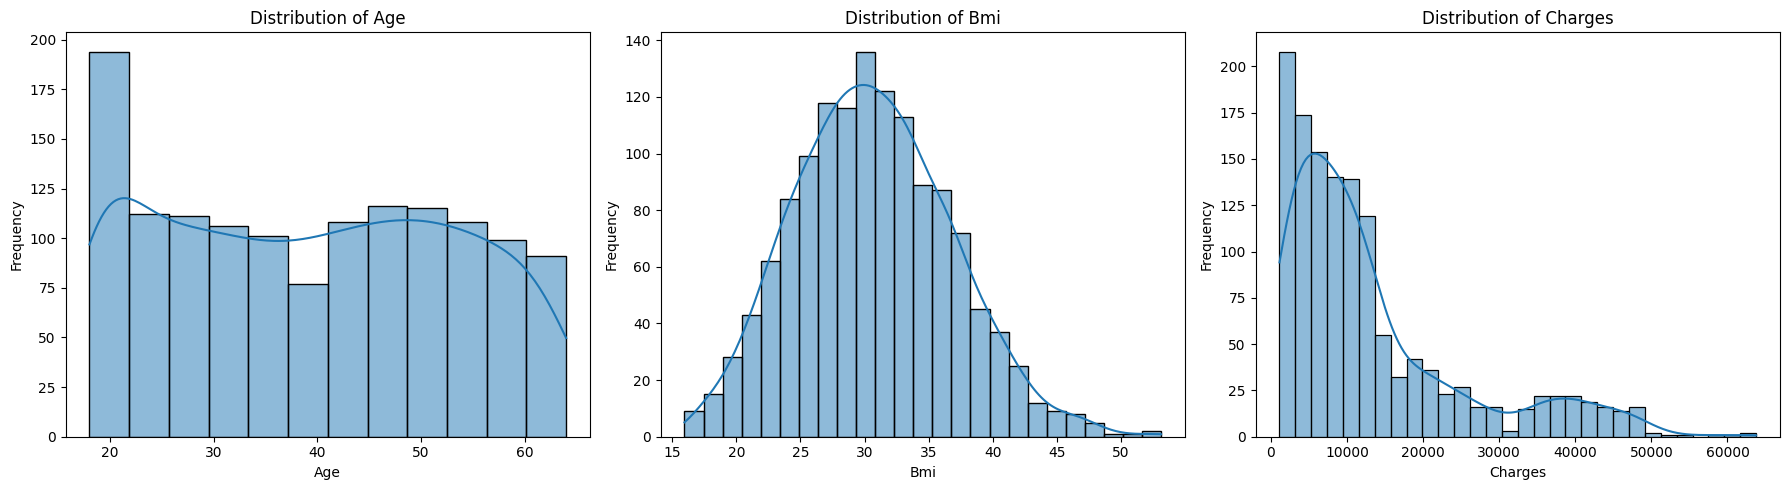

In [ ]:
numerical_features = ['age', 'bmi', 'charges']

plt.figure(figsize=(18, 5))

for i, feature in enumerate(numerical_features):
    plt.subplot(1, 3, i + 1)
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature.capitalize()}')
    plt.xlabel(feature.capitalize())
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

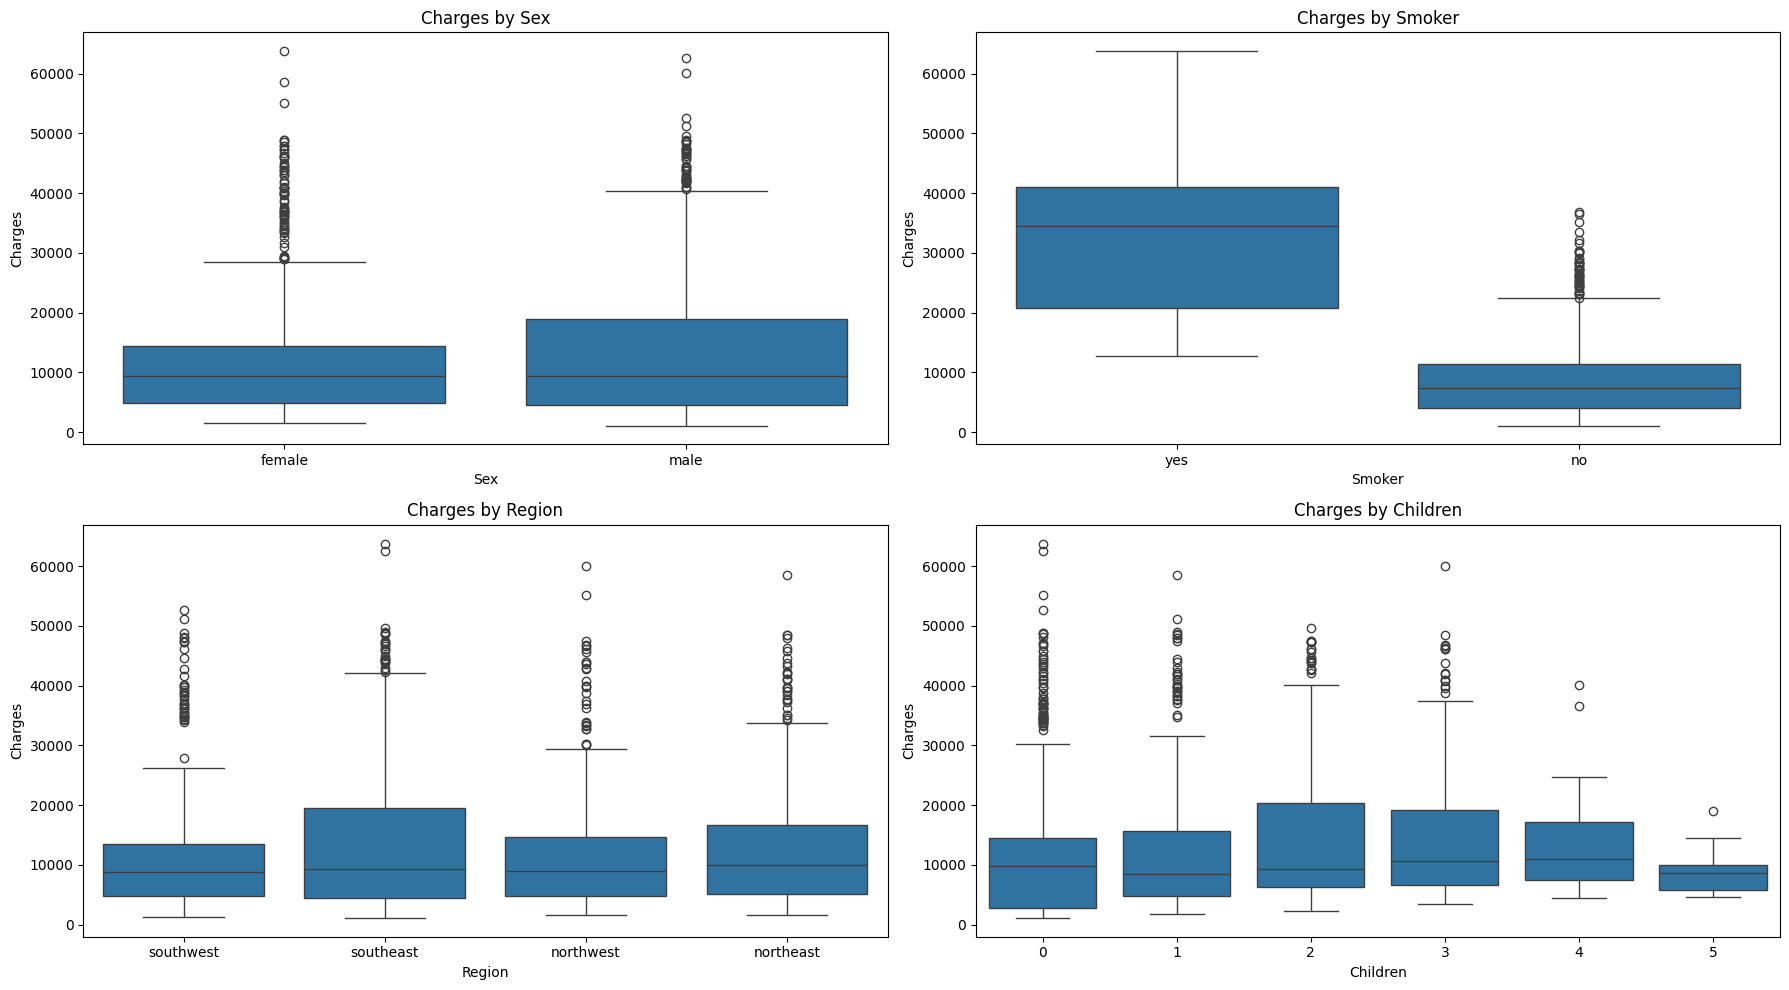

In [ ]:
categorical_features_for_boxplots = ['sex', 'smoker', 'region', 'children']

plt.figure(figsize=(18, 10)) # Adjust figure size for better visibility of 4 plots

for i, feature in enumerate(categorical_features_for_boxplots):
    plt.subplot(2, 2, i + 1) # Create a 2x2 grid for 4 plots
    sns.boxplot(x=feature, y='charges', data=df)
    plt.title(f'Charges by {feature.capitalize()}')
    plt.xlabel(feature.capitalize())
    plt.ylabel('Charges')

plt.tight_layout()
plt.show()

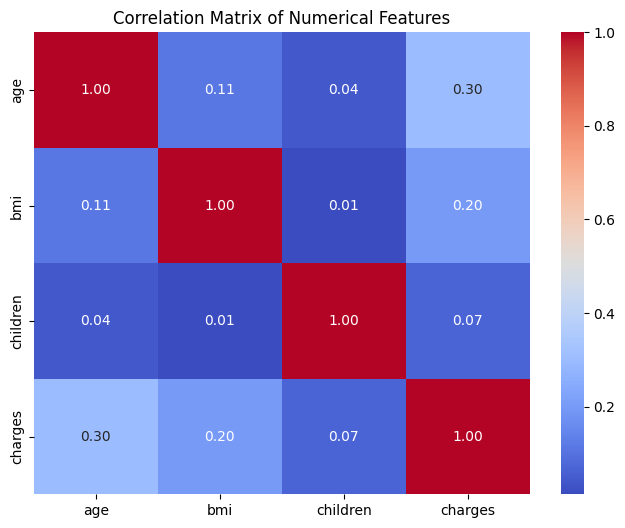

In [ ]:
numerical_cols_for_corr = ['age', 'bmi', 'children', 'charges']
correlation_matrix = df[numerical_cols_for_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Reload the original dataframe to ensure 'region' column is always present
df = pd.read_csv('/content/insurance.csv')

label_encoder_sex = LabelEncoder()
label_encoder_smoker = LabelEncoder()

# Apply Label Encoding for 'sex' and 'smoker'
df['sex'] = label_encoder_sex.fit_transform(df['sex'])
df['smoker'] = label_encoder_smoker.fit_transform(df['smoker'])

# Apply One-Hot Encoding for 'region'
df = pd.get_dummies(df, columns=['region'], drop_first=True, dtype=int)

print("Categorical features encoded successfully using a mix of LabelEncoder and One-Hot Encoding.")
print(df.head())

Categorical features encoded successfully using a mix of LabelEncoder and One-Hot Encoding.
   age  sex     bmi  children  smoker      charges  region_northwest  \
0   19    0  27.900         0       1  16884.92400                 0   
1   18    1  33.770         1       0   1725.55230                 0   
2   28    1  33.000         3       0   4449.46200                 0   
3   33    1  22.705         0       0  21984.47061                 1   
4   32    1  28.880         0       0   3866.85520                 1   

   region_southeast  region_southwest  
0                 0                 1  
1                 1                 0  
2                 1                 0  
3                 0                 0  
4                 0                 0  


In [ ]:
numerical_features_to_scale = ['age', 'bmi', 'children', 'charges']

scaler = StandardScaler()
df[numerical_features_to_scale] = scaler.fit_transform(df[numerical_features_to_scale])

print("Numerical features scaled successfully.")
print(df.head())

Numerical features scaled successfully.
        age  sex       bmi  children  smoker   charges  region_northwest  \
0 -1.438764    0 -0.453320 -0.908614       1  0.298584                 0   
1 -1.509965    1  0.509621 -0.078767       0 -0.953689                 0   
2 -0.797954    1  0.383307  1.580926       0 -0.728675                 0   
3 -0.441948    1 -1.305531 -0.908614       0  0.719843                 1   
4 -0.513149    1 -0.292556 -0.908614       0 -0.776802                 1   

   region_southeast  region_southwest  
0                 0                 1  
1                 1                 0  
2                 1                 0  
3                 0                 0  
4                 0                 0  


In [ ]:
X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shapes of the training and testing sets:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Shapes of the training and testing sets:
X_train shape: (1070, 8)
X_test shape: (268, 8)
y_train shape: (1070,)
y_test shape: (268,)


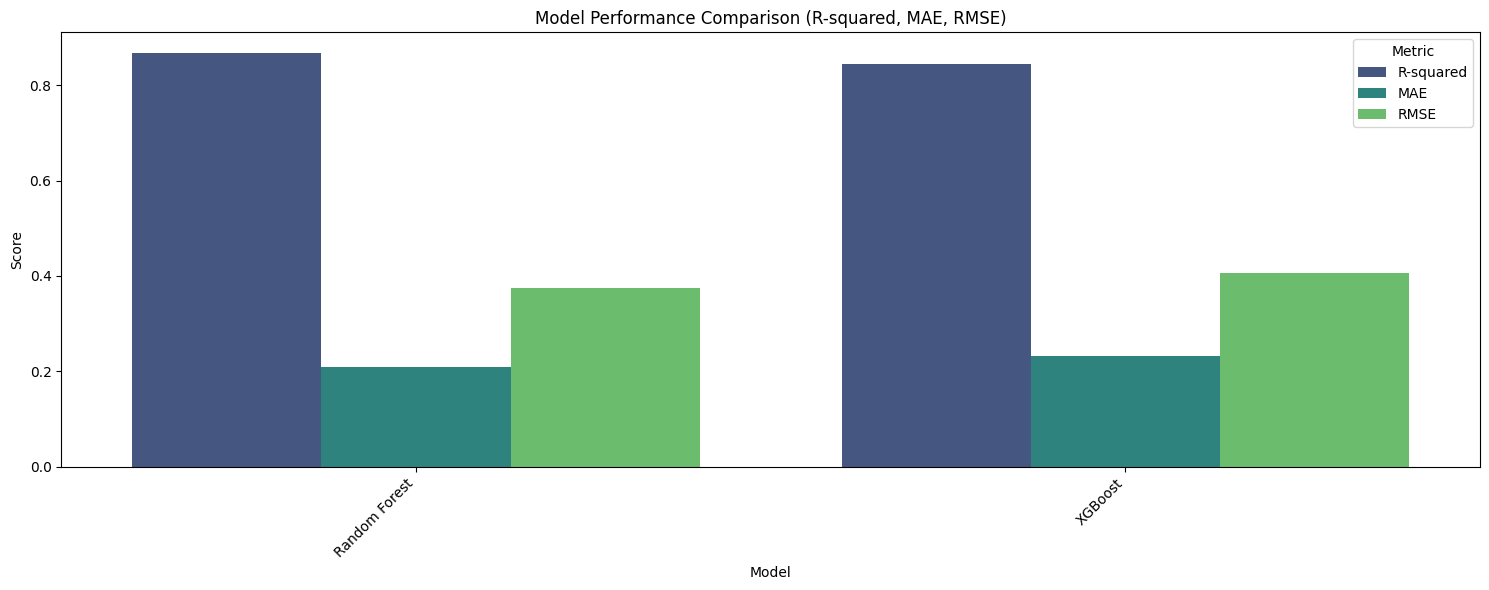

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import xgboost as xgb

# --- Random Forest Model Training and Evaluation ---
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

# --- XGBoost Model Training and Evaluation ---
xgb_model = xgb.XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
r2_xgb = r2_score(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

# --- Create DataFrame for Model Performance ---
performance_data = {
    'Model': ['Random Forest', 'XGBoost'],
    'R-squared': [r2_rf, r2_xgb],
    'MAE': [mae_rf, mae_xgb],
    'RMSE': [rmse_rf, rmse_xgb]
}
performance_df = pd.DataFrame(performance_data)

# Assign to performance_df_combined for consistency with subsequent cells
performance_df_combined = performance_df

# --- Prepare data for plotting ---
metrics_df_melted = performance_df.melt(id_vars='Model', var_name='Metric', value_name='Value')

plt.figure(figsize=(15, 6))
sns.barplot(x='Model', y='Value', hue='Metric', data=metrics_df_melted, palette='viridis')
plt.title('Model Performance Comparison (R-squared, MAE, RMSE)')
plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

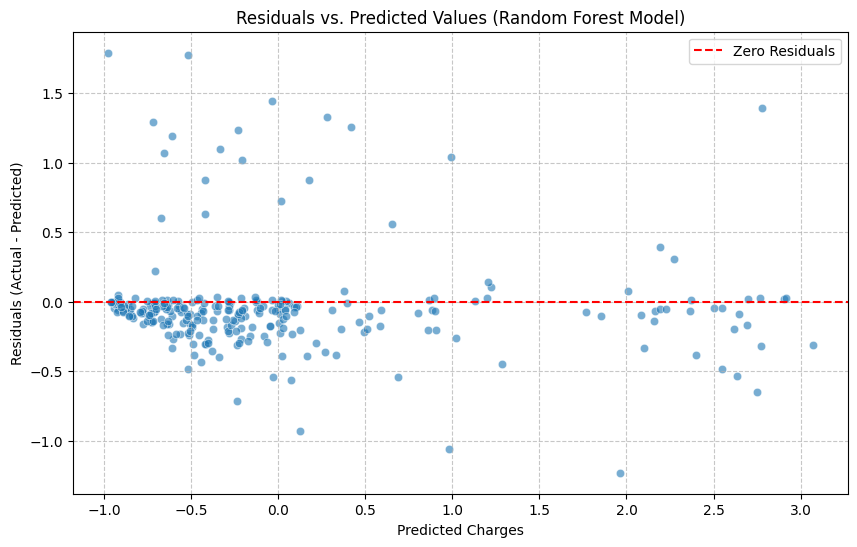

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals for the Random Forest model
residuals_rf = y_test - y_pred_rf

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_rf, y=residuals_rf, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', label='Zero Residuals')
plt.title('Residuals vs. Predicted Values (Random Forest Model)')
plt.xlabel('Predicted Charges')
plt.ylabel('Residuals (Actual - Predicted)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
# Initialize the Random Forest Regressor model
rf_model = RandomForestRegressor(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Calculate evaluation metrics
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

# Print the metrics
print("Random Forest Regressor Model Performance:")
print(f"R-squared: {r2_rf:.4f}")
print(f"Mean Absolute Error (MAE): {mae_rf:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.4f}")

Random Forest Regressor Model Performance:
R-squared: 0.8672
Mean Absolute Error (MAE): 0.2096
Root Mean Squared Error (RMSE): 0.3751


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import xgboost as xgb

# Initialize the XGBoost Regressor model
xgb_model = xgb.XGBRegressor(random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Calculate evaluation metrics
r2_xgb = r2_score(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

# Print the metrics
print("XGBoost Regressor Model Performance:")
print(f"R-squared: {r2_xgb:.4f}")
print(f"Mean Absolute Error (MAE): {mae_xgb:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.4f}")

XGBoost Regressor Model Performance:
R-squared: 0.8450
Mean Absolute Error (MAE): 0.2315
Root Mean Squared Error (RMSE): 0.4052


In [ ]:
#using DummyRegressor to show the model performance
from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)
r2_dummy = r2_score(y_test, y_pred_dummy)
mae_dummy = mean_absolute_error(y_test, y_pred_dummy)
rmse_dummy = np.sqrt(mean_squared_error(y_test, y_pred_dummy))
print("Dummy Model Performance:")
print(r2_dummy)
print(mae_dummy)
print(rmse_dummy)

Dummy Model Performance:
-0.0009192486886582252
0.7924786557687851
1.0297489499083408


In [ ]:
import pandas as pd

# Display the combined performance DataFrame
print("Combined Model Performance Summary:\n")
display(performance_df_combined)

# Identify the best model based on R-squared
best_model_row = performance_df_combined.loc[performance_df_combined['R-squared'].idxmax()]
best_model_name = best_model_row['Model']
best_r2 = best_model_row['R-squared']
best_mae = best_model_row['MAE']
best_rmse = best_model_row['RMSE']

print(f"\nBased on the R-squared metric, the best performing model is: {best_model_name}")
print(f"  R-squared: {best_r2:.4f}")
print(f"  Mean Absolute Error (MAE): {best_mae:.2f}")
print(f"  Root Mean Squared Error (RMSE): {best_rmse:.2f}")

Combined Model Performance Summary:



,Model,R-squared,MAE,RMSE
0,Random Forest,0.867176,0.209573,0.375120
1,XGBoost,0.845011,0.231500,0.405211



Based on the R-squared metric, the best performing model is: Random Forest
  R-squared: 0.8672
  Mean Absolute Error (MAE): 0.21
  Root Mean Squared Error (RMSE): 0.38


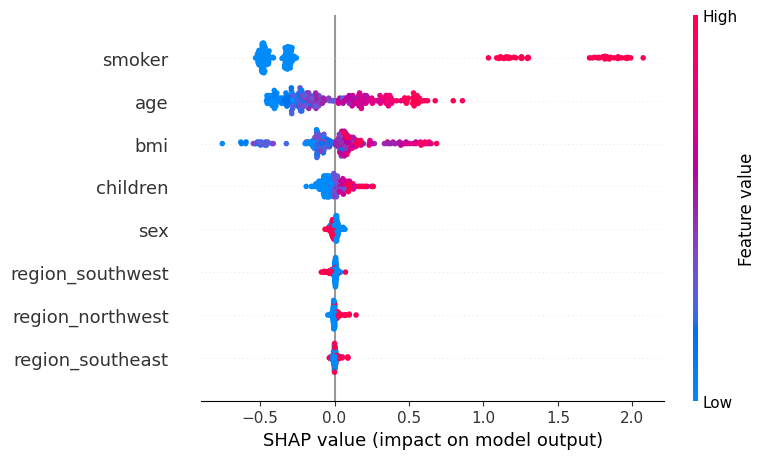

In [ ]:
import shap
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

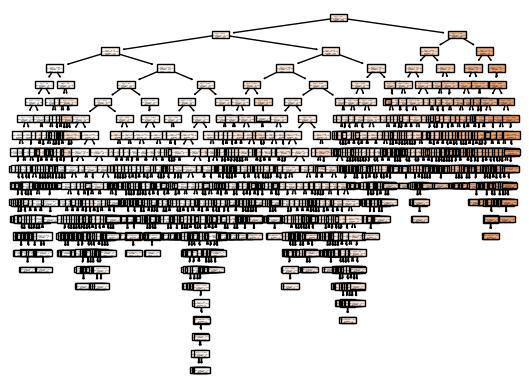

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plot_tree(rf_model.estimators_[0], filled=True)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
# Rely on the globally defined label_encoder_sex, label_encoder_smoker, and scaler
# which were fitted during the main data preprocessing steps.

def predict_charges(age, sex, bmi, children, smoker, region):
    # 1. Encode categorical features 'sex' and 'smoker' using their respective global LabelEncoders
    sex_encoded = label_encoder_sex.transform([sex])[0]
    smoker_encoded = label_encoder_smoker.transform([smoker])[0]

    # 2. Prepare one-hot encoded 'region' features
    # The columns created by pd.get_dummies were region_northwest, region_southeast, region_southwest
    region_northwest = 1 if region == 'northwest' else 0
    region_southeast = 1 if region == 'southeast' else 0
    region_southwest = 1 if region == 'southwest' else 0

    # 3. Create a DataFrame for the input, ensuring correct column order and names as X_train
    # X_train columns: age, sex, bmi, children, smoker, region_northwest, region_southeast, region_southwest
    input_data = {
        'age': age,
        'sex': sex_encoded,
        'bmi': bmi,
        'children': children,
        'smoker': smoker_encoded,
        'region_northwest': region_northwest,
        'region_southeast': region_southeast,
        'region_southwest': region_southwest
    }
    input_df = pd.DataFrame([input_data])

    # 4. Scale the numerical features using the global scaler
    # The scaler was fitted on ['age', 'bmi', 'children', 'charges'].
    # We only need to scale the input numerical features (age, bmi, children).
    # Create a temporary array with the input age, bmi, children, and a dummy value for charges (e.g., 0)
    temp_array_for_scaling = np.zeros((1, len(numerical_features_to_scale))) # numerical_features_to_scale is global
    temp_array_for_scaling[0, numerical_features_to_scale.index('age')] = age
    temp_array_for_scaling[0, numerical_features_to_scale.index('bmi')] = bmi
    temp_array_for_scaling[0, numerical_features_to_scale.index('children')] = children

    scaled_numerical_values = scaler.transform(temp_array_for_scaling)

    # Assign the scaled age, bmi, and children back to input_df
    input_df['age'] = scaled_numerical_values[0, numerical_features_to_scale.index('age')]
    input_df['bmi'] = scaled_numerical_values[0, numerical_features_to_scale.index('bmi')]
    input_df['children'] = scaled_numerical_values[0, numerical_features_to_scale.index('children')]

    # 5. Predict using the trained Random Forest model (rf_model is global)
    prediction_scaled = rf_model.predict(input_df)[0]

    # 6. Inverse transform the prediction to get the original charges scale
    # Create a dummy array with only the prediction value to inverse transform, maintaining the original feature count
    dummy_array = np.zeros((1, scaler.n_features_in_))
    dummy_array[0, numerical_features_to_scale.index('charges')] = prediction_scaled

    prediction_original_scale = scaler.inverse_transform(dummy_array)[0, numerical_features_to_scale.index('charges')]

    return max(0, prediction_original_scale) # Ensure charges are not negative


In [ ]:

# Create the Gradio interface
interface = gr.Interface(
    fn=predict_charges,
    inputs=[
        gr.Number(label="Age", value=30, minimum=18, maximum=64),
        gr.Dropdown(label="Sex", choices=['female', 'male'], value='female'),
        gr.Number(label="BMI", value=25.0, minimum=15.0, maximum=55.0),
        gr.Number(label="Children", value=0, minimum=0, maximum=5, step=1),
        gr.Dropdown(label="Smoker", choices=['no', 'yes'], value='no'),
        gr.Dropdown(label="Region", choices=['southwest', 'southeast', 'northwest', 'northeast'], value='southwest')
    ],
    outputs=gr.Number(label="Predicted Insurance Charges"),
    title="Insurance Charges Prediction",
    description="Enter patient details to predict insurance charges."
)

# Launch the interface
interface.launch(inline=True, share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9691bddc46ea72b217.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
